## Outliers Identification & Removal

In [1]:
import os
import random
import numpy as np
import pandas as pd

TRAIN_PATH = "kaggle/input/pirate_pain_train.csv"
TRAIN_LABELS_PATH = "kaggle/input/pirate_pain_train_labels.csv"
TEST_PATH = "kaggle/input/pirate_pain_test.csv"

train_df = pd.read_csv(TRAIN_PATH)
train_labels_df = pd.read_csv(TRAIN_LABELS_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape (features):", train_df.shape)
print("Train labels shape:", train_labels_df.shape)
print("Test shape:", test_df.shape)

# Merge labels into train_df on sample_index (rename if needed)
ID_COL = "sample_index"
TIME_COL = "time"
TARGET_COL = "label"
STATIC_COL = "is_pirate"  # static flag

train_df = train_df.merge(train_labels_df[[ID_COL, TARGET_COL]], on=ID_COL, how="left")

print("\nTrain columns:", train_df.columns.tolist())
print("Example rows:")
display(train_df.head())

Train shape (features): (105760, 40)
Train labels shape: (661, 2)
Test shape: (211840, 40)

Train columns: ['sample_index', 'time', 'pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4', 'n_legs', 'n_hands', 'n_eyes', 'joint_00', 'joint_01', 'joint_02', 'joint_03', 'joint_04', 'joint_05', 'joint_06', 'joint_07', 'joint_08', 'joint_09', 'joint_10', 'joint_11', 'joint_12', 'joint_13', 'joint_14', 'joint_15', 'joint_16', 'joint_17', 'joint_18', 'joint_19', 'joint_20', 'joint_21', 'joint_22', 'joint_23', 'joint_24', 'joint_25', 'joint_26', 'joint_27', 'joint_28', 'joint_29', 'joint_30', 'label']
Example rows:


,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30,label
0,0,0,2,0,2,1,two,two,two,1.094705,...,1.945042e-06,0.000004,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0.5,no_pain
1,0,1,2,2,2,2,two,two,two,1.135183,...,6.765107e-07,0.000006,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0.5,no_pain
2,0,2,2,0,2,2,two,two,two,1.080745,...,1.698525e-07,0.000001,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105,0.5,no_pain
3,0,3,2,2,2,2,two,two,two,0.938017,...,5.511079e-07,0.000002,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648,0.5,no_pain
4,0,4,2,2,2,2,two,two,two,1.090185,...,1.735459e-07,0.000002,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328,0.5,no_pain


In [2]:
def check_pirate(row):
    return 0 if row.get("n_legs", "two") == "two" else 1

if "n_legs" in train_df.columns:
    train_df["is_pirate"] = train_df.apply(check_pirate, axis=1)
    test_df["is_pirate"]  = test_df.apply(check_pirate, axis=1)

    for col in ["n_legs", "n_hands", "n_eyes"]:
        if col in train_df.columns:
            train_df.drop(columns=col, inplace=True)
        if col in test_df.columns:
            test_df.drop(columns=col, inplace=True)

if "joint_30" in train_df.columns:
    train_df.drop(columns="joint_30", inplace=True)
if "joint_30" in test_df.columns:
    test_df.drop(columns="joint_30", inplace=True)

train_df.head()

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,...,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,label,is_pirate
0,0,0,2,0,2,1,1.094705,0.985281,1.018302,1.010385,...,1.945042e-06,0.000004,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815,no_pain,0
1,0,1,2,2,2,2,1.135183,1.021175,0.994343,1.052364,...,6.765107e-07,0.000006,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716,no_pain,0
2,0,2,2,0,2,2,1.080745,0.962842,1.009588,0.977169,...,1.698525e-07,0.000001,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105,no_pain,0
3,0,3,2,2,2,2,0.938017,1.081592,0.998021,0.987283,...,5.511079e-07,0.000002,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648,no_pain,0
4,0,4,2,2,2,2,1.090185,1.032145,1.008710,0.963658,...,1.735459e-07,0.000002,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328,no_pain,0


In [ ]:
# Outliers detection and correction

# Get joints only
JOINT_COLS = [c for c in train_df.columns if c.startswith("joint_")]
print("Number of joint features:", len(JOINT_COLS))


def compute_global_thresholds(df, joint_cols, q=0.999, multiplier=10.0):
    """
    For each joint, compute a very high quantile and push it up by a multiplier.
    Values above this are 'candidate' extreme spikes.
    """
    thresholds = {}
    for c in joint_cols:
        q_high = df[c].quantile(q)
        thresholds[c] = float(q_high * multiplier)
    return thresholds


def correct_glitches(
    df,
    joint_cols,
    thresholds,
    id_col="sample_index",
    time_col="time",
    ratio_thresh=1e4,
    verbose=True,
    labels_df=None,
    label_col="label",
    exclude_labels=None,
):
    """
    Detect and correct glitches.

    Logic per subject & joint:
    1. Mark candidate points where value > thresholds[col].
    2. Group candidates into contiguous runs [a, b].
    3. For each run, compare its max to neighbours (within ±2 steps).
       If max / mean(neighbours) >= ratio_thresh -> glitch.
    4. Interpolate over [a, b]:
       - If both left and right neighbours exist: linear interpolation.
       - If only one side exists: fill with that neighbour's value.
       - If no neighbours: skip (very unlikely).
    
    Parameters:
    -----------
    labels_df : pd.DataFrame, optional
        DataFrame with labels to join on id_col. If provided, enables label-based filtering.
    label_col : str, default="label"
        Name of the label column in labels_df or df.
    exclude_labels : list, optional
        List of label values to exclude from correction (e.g., ['high_pain', 'low_pain']).
        Rows with these labels will not be corrected.
    
    Returns a small summary dict.
    """
    import math
    import numpy as np

    eps = 1e-12
    total_cells = 0
    total_segments = 0
    corrections_log = []
    
    # Merge labels if provided
    working_df = df
    if labels_df is not None:
        if label_col not in df.columns:
            working_df = df.merge(labels_df[[id_col, label_col]], on=id_col, how="left")
    
    # Build exclusion mask if needed
    exclude_mask = None
    if exclude_labels is not None and label_col in working_df.columns:
        exclude_mask = working_df[label_col].isin(exclude_labels)

    # Iterate over subjects
    for sid in df[id_col].unique():
        sub_mask = df[id_col] == sid
        # Ensure proper time ordering
        sub_idx_sorted = df.loc[sub_mask].sort_values(time_col).index
        times = df.loc[sub_idx_sorted, time_col].to_numpy()
        nT = len(sub_idx_sorted)
        
        # Check if any rows in this subject should be excluded
        if exclude_mask is not None:
            subject_exclude_mask = exclude_mask.loc[sub_idx_sorted].to_numpy()
        else:
            subject_exclude_mask = None

        for col in joint_cols:
            # Original values for detection and neighbours
            vals_orig = df.loc[sub_idx_sorted, col].to_numpy(dtype=float)
            vals_new = vals_orig.copy()

            # 1) Candidate extreme spikes (global)
            cand = vals_orig > thresholds[col]
            if not np.any(cand):
                continue

            cand_idx = np.where(cand)[0]

            # 2) Find contiguous runs [a, b]
            runs = []
            start = cand_idx[0]
            prev = cand_idx[0]
            for k in cand_idx[1:]:
                if k == prev + 1:
                    prev = k
                else:
                    runs.append((start, prev))
                    start = k
                    prev = k
            runs.append((start, prev))

            # 3) For each run, check if it's a Tier-A glitch & interpolate
            for a, b in runs:
                # Skip correction if any point in the run has an excluded label
                if subject_exclude_mask is not None:
                    if np.any(subject_exclude_mask[a:b + 1]):
                        continue
                
                # Neighbours outside the run (up to ±2 steps)
                neighbour_idxs = []
                if a - 1 >= 0:
                    neighbour_idxs.append(a - 1)
                if a - 2 >= 0:
                    neighbour_idxs.append(a - 2)
                if b + 1 < nT:
                    neighbour_idxs.append(b + 1)
                if b + 2 < nT:
                    neighbour_idxs.append(b + 2)
                neighbour_idxs = sorted(set(neighbour_idxs))

                if not neighbour_idxs:
                    # No context -> skip, nothing sensible to interpolate from
                    continue

                neighbour_vals = np.abs(vals_orig[neighbour_idxs])
                local_mean = neighbour_vals.mean()

                seg_vals = np.abs(vals_orig[a:b + 1])
                seg_max = seg_vals.max()

                if local_mean < eps:
                    ratio = math.inf if seg_max > 0 else 1.0
                else:
                    ratio = float(seg_max / (local_mean + eps))

                # Very big globally *and* vs neighbours
                if seg_max > thresholds[col] and ratio >= ratio_thresh:
                    time_start = times[a]
                    time_end = times[b]
                    original_vals = vals_orig[a:b + 1].copy()
                    
                    # Glitch: interpolate across the whole [a, b] segment
                    left_idx = a - 1 if a - 1 >= 0 else None
                    right_idx = b + 1 if b + 1 < nT else None

                    left_val = vals_orig[left_idx] if left_idx is not None else None
                    right_val = vals_orig[right_idx] if right_idx is not None else None

                    if (left_val is not None) and (right_val is not None):
                        # Linear interpolation between left and right
                        length = right_idx - left_idx + 1
                        interp = np.linspace(left_val, right_val, length)
                        # Positions 1..-2 correspond to indices a..b
                        vals_new[a:b + 1] = interp[1:-1]
                        correction_type = "linear_interp"
                    elif left_val is not None:
                        # Only left neighbour -> constant fill
                        vals_new[a:b + 1] = left_val
                        correction_type = "left_fill"
                    elif right_val is not None:
                        # Only right neighbour -> constant fill
                        vals_new[a:b + 1] = right_val
                        correction_type = "right_fill"
                    # else: no neighbours, already handled above

                    # Log the correction
                    corrections_log.append({
                        'sample_index': sid,
                        'joint': col,
                        'time_start': time_start,
                        'time_end': time_end,
                        'num_points': b - a + 1,
                        'original_max': seg_max,
                        'neighbour_mean': local_mean,
                        'ratio': ratio,
                        'correction_type': correction_type,
                        'original_values': original_vals.tolist(),
                        'corrected_values': vals_new[a:b + 1].tolist()
                    })
                    
                    total_segments += 1
                    total_cells += (b - a + 1)

            # Assign corrected values back (if they changed)
            if not np.allclose(vals_new, vals_orig):
                df.loc[sub_idx_sorted, col] = vals_new

    if verbose:
        print(f"\n{'='*80}")
        print(f"Glitch Correction Summary")
        print(f"{'='*80}")
        print(f"Total cells corrected: {total_cells}")
        print(f"Total segments: {total_segments}")
        if exclude_labels:
            print(f"Excluded labels from correction: {exclude_labels}")
        print(f"\nDetailed corrections:")
        print(f"{'-'*80}")
        
        for i, log in enumerate(corrections_log, 1):
            print(f"\nCorrection #{i}:")
            print(f"  Patient: {log['sample_index']}")
            print(f"  Joint: {log['joint']}")
            print(f"  Time range: {log['time_start']} to {log['time_end']} ({log['num_points']} points)")
            print(f"  Original max value: {log['original_max']:.8f}")
            print(f"  Neighbour mean: {log['neighbour_mean']:.8f}")
            print(f"  Ratio (max/neighbour): {log['ratio']:.1f}")
            print(f"  Correction method: {log['correction_type']}")
            print(f"  Original values: {[f'{v:.8f}' for v in log['original_values']]}")
            print(f"  Corrected values: {[f'{v:.8f}' for v in log['corrected_values']]}")
        
        print(f"\n{'='*80}\n")
    
    return {
        "total_cells_corrected": total_cells, 
        "total_segments": total_segments,
        "corrections_log": corrections_log
    }


Number of joint features: 30


In [4]:
GLITCH_QUANTILE = 0.999   # very high quantile
GLITCH_MULTIPLIER = 10.0  # how much above that quantile to call it "candidate"
RATIO_THRESH = 1e4       # how much bigger than local neighbours to be a glitch

global_thresholds = compute_global_thresholds(
    train_df,
    JOINT_COLS,
    q=GLITCH_QUANTILE,
    multiplier=GLITCH_MULTIPLIER,
)

# Apply correction to train set
train_glitches_summary = correct_glitches(
    train_df,
    JOINT_COLS,
    global_thresholds,
    id_col=ID_COL,
    time_col=TIME_COL,
    ratio_thresh=RATIO_THRESH,
    verbose=True,
    labels_df=train_labels_df,
    label_col="label",
    exclude_labels=['high_pain']
)

print("Train glitches summary:", train_glitches_summary)


Glitch Correction Summary
Total cells corrected: 7
Total segments: 4
Excluded labels from correction: ['high_pain']

Detailed corrections:
--------------------------------------------------------------------------------

Correction #1:
  Patient: 465
  Joint: joint_21
  Time range: 130 to 131 (2 points)
  Original max value: 1.44219835
  Neighbour mean: 0.00000126
  Ratio (max/neighbour): 1141374.9
  Correction method: linear_interp
  Original values: ['0.14999792', '1.44219835']
  Corrected values: ['0.00000098', '0.00000195']

Correction #2:
  Patient: 465
  Joint: joint_22
  Time range: 130 to 131 (2 points)
  Original max value: 1.19339936
  Neighbour mean: 0.00000321
  Ratio (max/neighbour): 371591.0
  Correction method: linear_interp
  Original values: ['1.19339936', '0.15982912']
  Corrected values: ['0.00000326', '0.00000479']

Correction #3:
  Patient: 465
  Joint: joint_25
  Time range: 130 to 131 (2 points)
  Original max value: 0.94735400
  Neighbour mean: 0.00000596
  Rat

# Targeted Removal
A specific Function to eliminate particular suspicious spikes, as the one which I have previously identified in joint_21.

In [ ]:
# Clean very high spikes for a specific joint and label (e.g., joint_21, 'high_pain')
import numpy as np
import pandas as pd

def clean_joint_spikes_per_label(df: pd.DataFrame, joint_col: str, label_value: str, id_col: str, time_col: str,
                                  q: float = 0.999, ratio_thresh: float = 1_000.0, verbose: bool = True):
    """
    Detect and correct extreme spikes in `joint_col` but ONLY for rows with label == label_value.
    - Threshold: high quantile q computed within the selected label subset only
    - Spike rule: segment max > threshold and max/neighbour_mean >= ratio_thresh
    - Correction: linear interpolation across contiguous segments; fallback to constant from one side
    """
    assert joint_col in df.columns, f"Column {joint_col} not found"
    assert TARGET_COL in df.columns, "Label column not present; ensure merge was executed above."
    eps = 1e-12

    sub = df[df[TARGET_COL] == label_value]
    if sub.empty:
        if verbose:
            print(f"No rows for label={label_value}; nothing to clean.")
        return {"total_cells_corrected": 0, "total_segments": 0, "threshold": None}

    thr = float(sub[joint_col].quantile(q))
    total_cells = 0
    total_segments = 0

    # Work per subject to respect time ordering
    for sid in sub[id_col].unique():
        idx = df[(df[id_col] == sid) & (df[TARGET_COL] == label_value)].sort_values(time_col).index
        vals_orig = df.loc[idx, joint_col].to_numpy(dtype=float)
        vals_new  = vals_orig.copy()

        cand = vals_orig > thr
        if not np.any(cand):
            continue
        cand_idx = np.where(cand)[0]

        # Find contiguous candidate runs
        runs = []
        start = cand_idx[0]
        prev = cand_idx[0]
        for k in cand_idx[1:]:
            if k == prev + 1:
                prev = k
            else:
                runs.append((start, prev))
                start = k
                prev = k
        runs.append((start, prev))

        nT = len(vals_orig)
        for a, b in runs:
            # Neighbours outside the run (±2 steps)
            nb = []
            if a - 1 >= 0: nb.append(a - 1)
            if a - 2 >= 0: nb.append(a - 2)
            if b + 1 < nT: nb.append(b + 1)
            if b + 2 < nT: nb.append(b + 2)
            nb = sorted(set(nb))
            if not nb:
                continue
            local_mean = np.abs(vals_orig[nb]).mean()
            seg_max = np.abs(vals_orig[a:b+1]).max()
            ratio = (seg_max / (local_mean + eps)) if local_mean > 0 else (np.inf if seg_max > 0 else 1.0)

            if (seg_max > thr) and (ratio >= ratio_thresh):
                # Interpolate across [a,b]
                left_idx = a - 1 if a - 1 >= 0 else None
                right_idx = b + 1 if b + 1 < nT else None
                left_val = vals_orig[left_idx] if left_idx is not None else None
                right_val = vals_orig[right_idx] if right_idx is not None else None
                if (left_val is not None) and (right_val is not None):
                    length = right_idx - left_idx + 1
                    interp = np.linspace(left_val, right_val, length)
                    vals_new[a:b+1] = interp[1:-1]
                elif left_val is not None:
                    vals_new[a:b+1] = left_val
                elif right_val is not None:
                    vals_new[a:b+1] = right_val
                total_segments += 1
                total_cells += (b - a + 1)

        if not np.allclose(vals_new, vals_orig):
            df.loc[idx, joint_col] = vals_new
predict_logits
    if verbose:
        print(f"Cleaned {total_cells} cells across {total_segments} segments on {joint_col} for label={label_value} (thr q={q})")
    return {"total_cells_corrected": total_cells, "total_segments": total_segments, "threshold": thr}

# Apply cleaning to joint_21 for 'high_pain'
joint_to_fix = 'joint_21' if 'joint_21' in train_df.columns else ('joint_21' if 'joint_21' in train_df.columns else None)
assert joint_to_fix is not None, "joint_21 column not found."
_ = clean_joint_spikes_per_label(train_df, joint_to_fix, 'high_pain', ID_COL, TIME_COL, q=0.999, ratio_thresh=1000.0, verbose=True)

Cleaned 3 cells across 2 segments on joint_21 for label=high_pain (thr q=0.999)


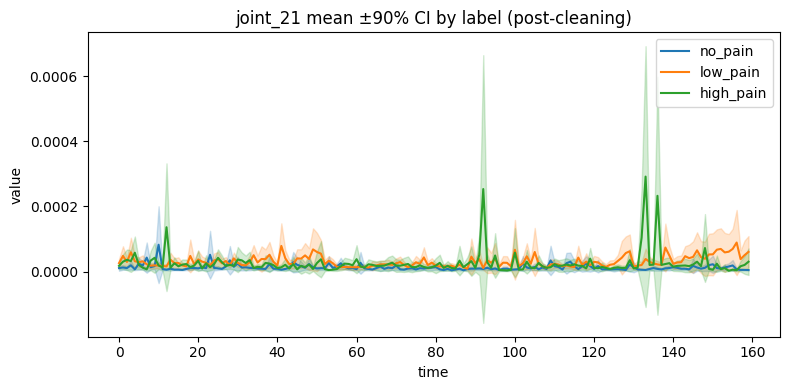

In [6]:
# Re-plot joint_21 after cleaning: mean and ~90% CI per label
import matplotlib.pyplot as plt
import numpy as np

joint_col = 'joint_21'
assert joint_col in train_df.columns, f"Column {joint_col} not found in train_df"

times = np.sort(train_df[TIME_COL].unique())
preferred_order = ['no_pain', 'low_pain', 'high_pain']
labels_avail = train_df[TARGET_COL].dropna().unique().tolist()
plot_labels = [l for l in preferred_order if l in labels_avail] or sorted(labels_avail)
palette = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5']

plt.figure(figsize=(8, 4))
for li, label in enumerate(plot_labels):
    sub = train_df.loc[train_df[TARGET_COL] == label, [ID_COL, TIME_COL, joint_col]].dropna()
    if sub.empty:
        continue
    mat = sub.pivot(index=ID_COL, columns=TIME_COL, values=joint_col)
    mat = mat.reindex(columns=times)
    mean = mat.mean(axis=0).to_numpy()
    if mat.shape[0] > 1:
        sem = mat.std(axis=0, ddof=1).to_numpy() / np.sqrt(mat.shape[0])
    else:
        sem = np.zeros_like(mean)
    ci = 1.645 * sem  # ~90% CI
    color = palette[li % len(palette)]
    plt.plot(times, mean, label=str(label), color=color)
    plt.fill_between(times, mean - ci, mean + ci, color=color, alpha=0.2)

plt.title(f'{joint_col} mean ±90% CI by label (post-cleaning)')
plt.xlabel('time')
plt.ylabel('value')
plt.legend()
plt.tight_layout()
plt.show()

## Per-Class Training Set Data Visualization on Joints

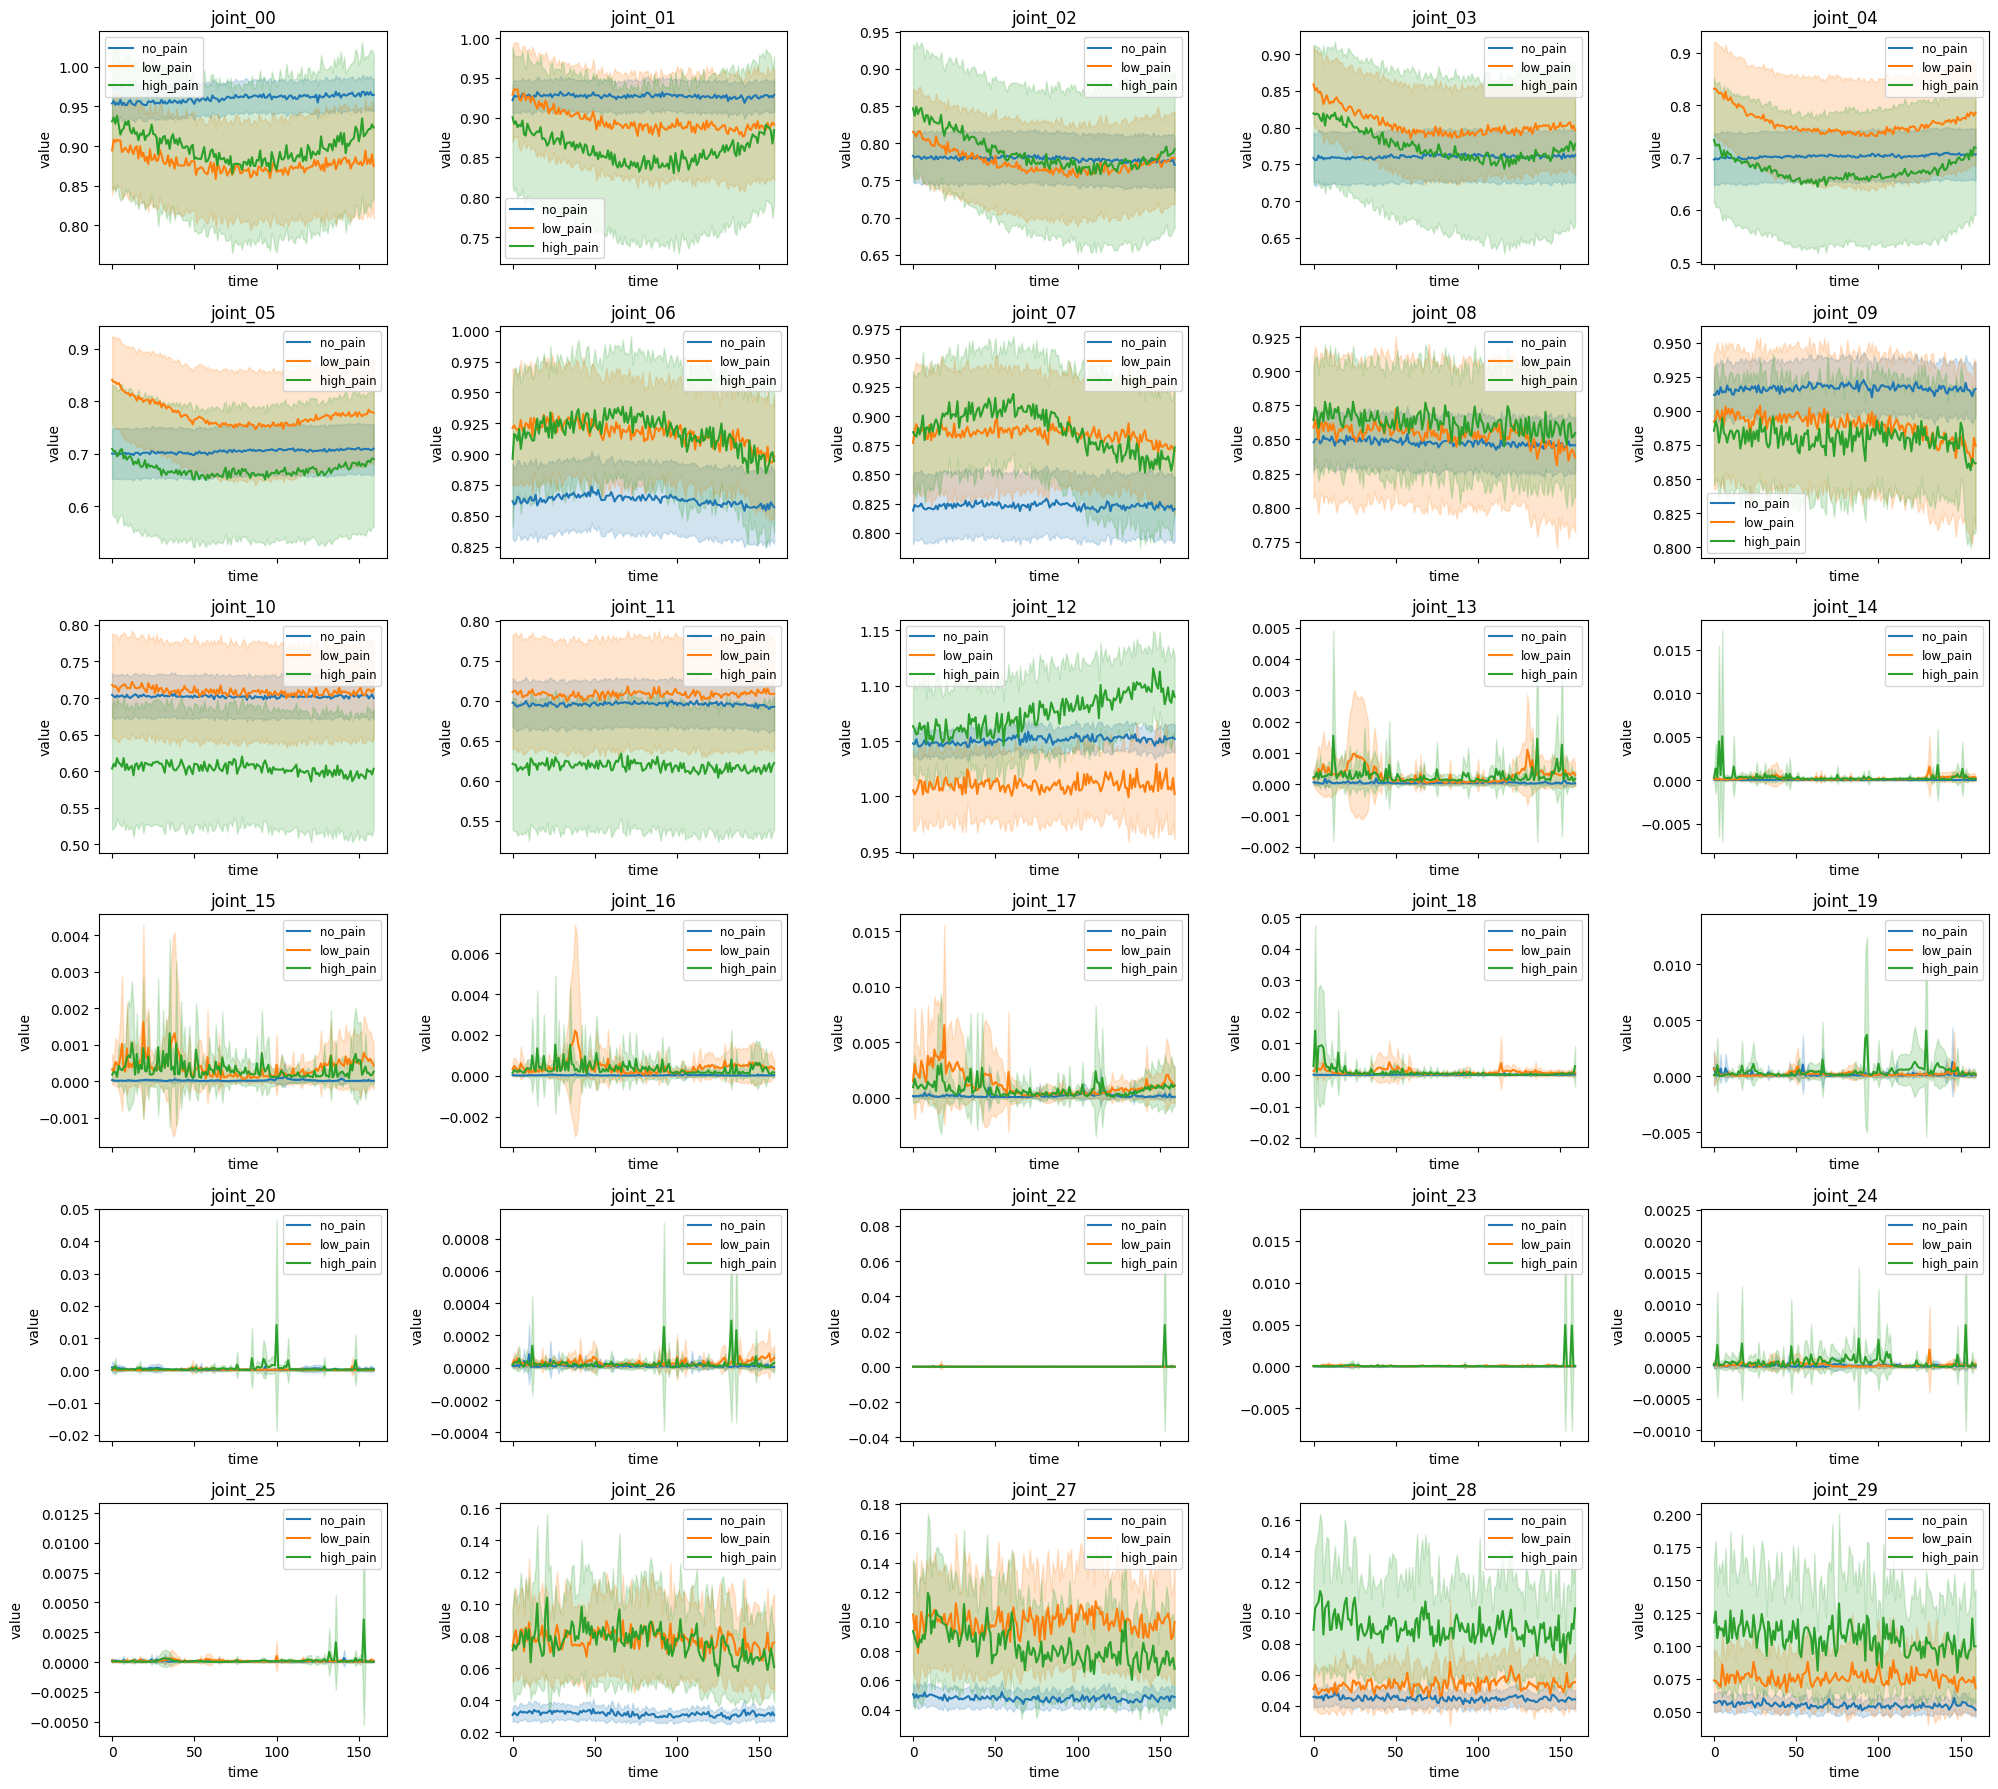

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Use labels already merged into train_df (TARGET_COL)
assert TARGET_COL in train_df.columns, "Label column not found in train_df. Ensure merge was executed above."

# Identify joint columns and time axis
joint_cols = [c for c in train_df.columns if c.startswith('joint_')]
times = np.sort(train_df[TIME_COL].unique())

# Define label display order and colors (fallback to sorted unique labels)
preferred_order = ['no_pain', 'low_pain', 'high_pain']
unique_labels = [l for l in preferred_order if l in train_df[TARGET_COL].unique().tolist()]
if len(unique_labels) == 0:
    unique_labels = sorted(train_df[TARGET_COL].dropna().unique().tolist())
palette = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5']

# Figure layout
n_joints = len(joint_cols)
ncols = 5
nrows = int(np.ceil(n_joints / ncols)) if n_joints > 0 else 1
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), sharex=True)
if isinstance(axes, np.ndarray):
    axes = axes.flatten()
else:
    axes = [axes]

# Plot per joint: mean curve with ~99% CI per label
for i, col in enumerate(joint_cols):
    ax = axes[i]
    for li, label in enumerate(unique_labels):
        sub = train_df.loc[train_df[TARGET_COL] == label, [ID_COL, TIME_COL, col]].dropna()
        if sub.empty:
            continue
        # Pivot to (n_samples_in_class, n_time) for this joint
        mat = sub.pivot(index=ID_COL, columns=TIME_COL, values=col)
        # Ensure consistent column (time) order
        mat = mat.reindex(columns=times)
        # Compute across-sample statistics at each time
        mean = mat.mean(axis=0).to_numpy()
        # If only one sample in class, SEM is zero to avoid NaNs
        if mat.shape[0] > 1:
            sem = mat.std(axis=0, ddof=1).to_numpy() / np.sqrt(mat.shape[0])
        else:
            sem = np.zeros_like(mean)
        ci = 2.576 * sem  # ~99% CI
        color = palette[li % len(palette)]
        ax.plot(times, mean, label=str(label), color=color)
        ax.fill_between(times, mean - ci, mean + ci, color=color, alpha=0.2)
    ax.set_title(col)
    ax.set_xlabel('time')
    ax.set_ylabel('value')
    ax.legend(fontsize='small')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Correlation Analysis

,joint_00,joint_01,joint_02,joint_03,joint_04,joint_05,joint_06,joint_07,joint_08,joint_09,...,joint_20,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29
joint_00,1.000,0.764,0.845,0.707,0.531,0.490,0.291,0.363,0.046,-0.041,...,0.005,-0.017,0.000,0.005,-0.004,-0.010,-0.159,-0.105,0.098,0.011
joint_01,0.764,1.000,0.681,0.817,0.454,0.596,0.345,0.412,0.056,-0.096,...,-0.003,-0.023,0.001,0.004,-0.009,-0.016,-0.129,-0.054,0.003,0.006
joint_02,0.845,0.681,1.000,0.835,0.769,0.683,0.370,0.450,0.032,-0.091,...,0.003,-0.004,0.002,0.006,-0.002,-0.006,-0.054,-0.014,0.136,0.047
joint_03,0.707,0.817,0.835,1.000,0.672,0.838,0.415,0.484,0.084,-0.101,...,0.001,-0.009,0.002,0.004,-0.001,-0.009,-0.025,0.028,0.066,0.041
joint_04,0.531,0.454,0.769,0.672,1.000,0.777,0.428,0.460,-0.014,-0.132,...,0.009,0.004,0.002,0.007,0.003,-0.002,0.077,0.107,0.120,0.038
joint_05,0.490,0.596,0.683,0.838,0.777,1.000,0.414,0.459,0.024,-0.118,...,0.004,0.002,0.002,0.002,-0.001,-0.004,0.058,0.104,0.060,-0.005
joint_06,0.291,0.345,0.370,0.415,0.428,0.414,1.000,0.828,0.040,-0.153,...,-0.008,0.004,0.002,0.004,0.020,-0.004,-0.003,-0.008,0.063,0.139
joint_07,0.363,0.412,0.450,0.484,0.460,0.459,0.828,1.000,0.017,-0.181,...,-0.056,-0.022,0.001,0.003,-0.018,-0.016,0.017,0.006,0.057,0.065
joint_08,0.046,0.056,0.032,0.084,-0.014,0.024,0.040,0.017,1.000,0.502,...,-0.021,0.021,-0.005,-0.004,0.017,0.031,-0.063,-0.093,-0.157,-0.015
joint_09,-0.041,-0.096,-0.091,-0.101,-0.132,-0.118,-0.153,-0.181,0.502,1.000,...,0.015,0.023,-0.015,-0.005,0.029,0.017,-0.075,-0.083,-0.082,-0.051


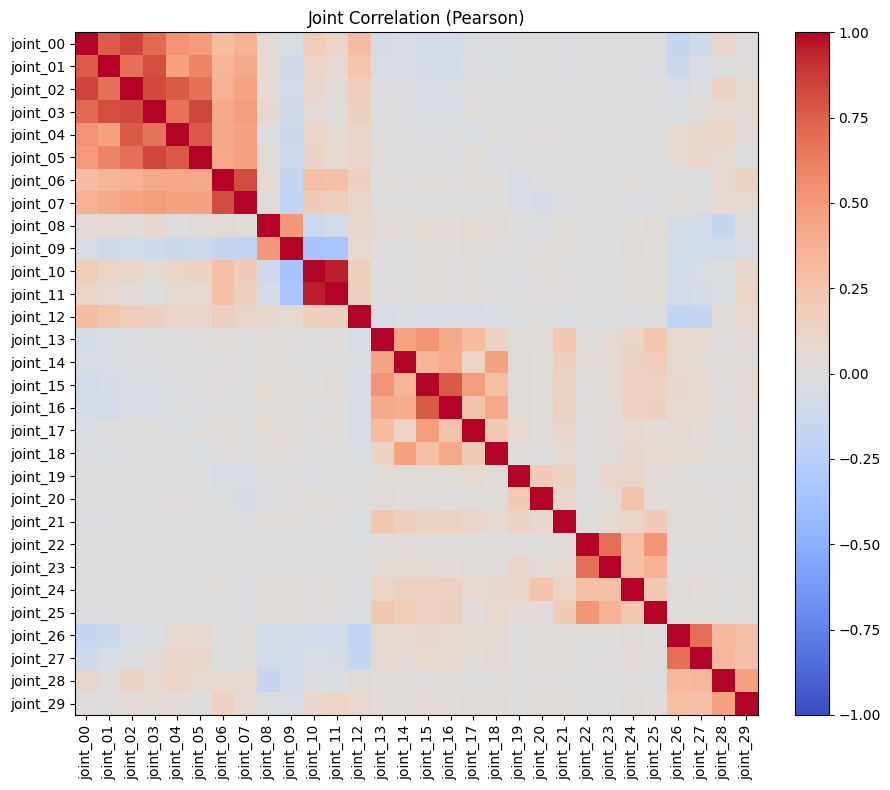

In [8]:
# 1) Compute Pearson correlations on joint columns (with optional sampling for speed)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

joint_cols = [c for c in train_df.columns if c.startswith('joint_')]
assert len(joint_cols) > 0, "No joint_* columns found."

MAX_ROWS_FOR_CORR = 250_000  # adjust for speed/cost effectiveness
if len(train_df) > MAX_ROWS_FOR_CORR:
    corr_df = train_df.sample(n=MAX_ROWS_FOR_CORR, random_state=42)
else:
    corr_df = train_df

corr = corr_df[joint_cols].corr(method='pearson')
display(corr.round(3))


plt.figure(figsize=(10, 8))
im = plt.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(joint_cols)), joint_cols, rotation=90)
plt.yticks(range(len(joint_cols)), joint_cols)
plt.title('Joint Correlation (Pearson)')
plt.tight_layout()
plt.show()

In [9]:
# 2) Extract redundant pairs and group near-duplicates

HIGH_DUP_THR = 0.75   # near-duplicate threshold
REDUNDANT_THR = 0.70  # high redundancy threshold

pairs = []
cols = joint_cols
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = float(corr.iloc[i, j])
        if abs(r) >= REDUNDANT_THR:
            pairs.append((cols[i], cols[j], r))

pairs_df = pd.DataFrame(pairs, columns=["a", "b", "corr"]).sort_values(
    by="corr", key=lambda s: s.abs(), ascending=False)
print(f"Found {len(pairs_df)} pairs with |r| >= {REDUNDANT_THR}")
display(pairs_df.head(30))

# Union-Find to group near-duplicates (|r| >= HIGH_DUP_THR)
parent = {c: c for c in cols}
def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x
def union(x, y):
    rx, ry = find(x), find(y)
    if rx != ry:
        parent[ry] = rx

for a, b, r in pairs:
    if abs(r) >= HIGH_DUP_THR:
        union(a, b)

groups = {}
for c in cols:
    root = find(c)
    groups.setdefault(root, []).append(c)

# Keep only groups with >1 members
def joint_sort_key(name: str):
    try:
        return int(name.split('_')[-1])
    except Exception:
        return name

dup_groups = {k: sorted(v, key=joint_sort_key) for k, v in groups.items() if len(v) > 1}
print(f"Near-duplicate groups (|r| >= {HIGH_DUP_THR}):")
for root, members in dup_groups.items():
    print(f"  {root}: {members}")

Found 11 pairs with |r| >= 0.7


,a,b,corr
9,joint_10,joint_11,0.949209
1,joint_00,joint_02,0.844885
6,joint_03,joint_05,0.837806
4,joint_02,joint_03,0.834983
8,joint_06,joint_07,0.827675
3,joint_01,joint_03,0.817127
7,joint_04,joint_05,0.776747
5,joint_02,joint_04,0.769236
10,joint_15,joint_16,0.766622
0,joint_00,joint_01,0.764235


Near-duplicate groups (|r| >= 0.75):
  joint_00: ['joint_00', 'joint_01', 'joint_02', 'joint_03', 'joint_04', 'joint_05']
  joint_06: ['joint_06', 'joint_07']
  joint_10: ['joint_10', 'joint_11']
  joint_15: ['joint_15', 'joint_16']
